***Customer Churn Analysis and Predictive Modeling Using Machine Learning Techniques***

## Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('telco_churn_cleaned.csv')

### Dataset Overview

In [ ]:
# Display the first 5 rows of the DataFrame
print('First 5 rows of the dataset:')
display(df.head())

First 5 rows of the dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,has_streaming
0,0002-ORFBO,Female,0,1,1,9,1,No,DSL,0,...,1,1,0,One year,1,Mailed check,65.6,593.30,0,1
1,0003-MKNFE,Male,0,0,0,9,1,Yes,DSL,0,...,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,0,1
2,0004-TLHLJ,Male,0,0,0,4,1,No,Fiber optic,0,...,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,1,0
3,0011-IGKFF,Male,1,1,0,13,1,No,Fiber optic,0,...,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,1,1
4,0013-EXCHZ,Female,1,1,0,3,1,No,Fiber optic,0,...,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,1,1


In [ ]:
# Display basic information about the DataFrame
print('\nDataFrame Info:')
df.info()

# Display descriptive statistics for numerical columns
print('\nDescriptive Statistics:')
display(df.describe())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   int64  
 4   Dependents        7043 non-null   int64  
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   int64  
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   int64  
 10  OnlineBackup      7043 non-null   int64  
 11  DeviceProtection  7043 non-null   int64  
 12  TechSupport       7043 non-null   int64  
 13  StreamingTV       7043 non-null   int64  
 14  StreamingMovies   7043 non-null   int64  
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 no

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,has_streaming
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,0.483033,0.299588,32.371149,0.903166,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2279.734304,0.265370,0.496805
std,0.368612,0.499748,0.458110,24.559481,0.295752,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2266.794470,0.441561,0.500025
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,398.550000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1394.550000,0.000000,0.000000
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,1.000000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,1.000000,1.000000


In [ ]:
# Check for missing values
print('\nMissing values per column:')
display(df.isnull().sum())


Missing values per column:


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Feature Analysis

In [ ]:
# Separate numerical and categorical features
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Numerical Columns: {numerical_cols}')
print(f'Categorical Columns: {categorical_cols}')

Numerical Columns: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'has_streaming']
Categorical Columns: ['customerID', 'gender', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']


In [ ]:
# Display value counts for categorical columns (top 10 if many unique values)
print('\nValue counts for categorical columns:')
for col in categorical_cols:
    print(f'\n--- {col} ---')
    if df[col].nunique() > 10:
        display(df[col].value_counts().head(10))
    else:
        display(df[col].value_counts())


Value counts for categorical columns:

--- customerID ---


,count
customerID,
9995-HOTOH,1
0002-ORFBO,1
0003-MKNFE,1
9970-QBCDA,1
9968-FFVVH,1
9967-ATRFS,1
9965-YOKZB,1
9964-WBQDJ,1
9962-BFPDU,1



--- gender ---


,count
gender,
Male,3555
Female,3488



--- MultipleLines ---


...

,count
InternetService,
Fiber optic,3096
DSL,2421
No,1526



--- Contract ---


,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473



--- PaymentMethod ---


,count
PaymentMethod,
Electronic check,2365
Mailed check,1612
Bank transfer,1544
Credit card,1522


### Visualizing Distributions

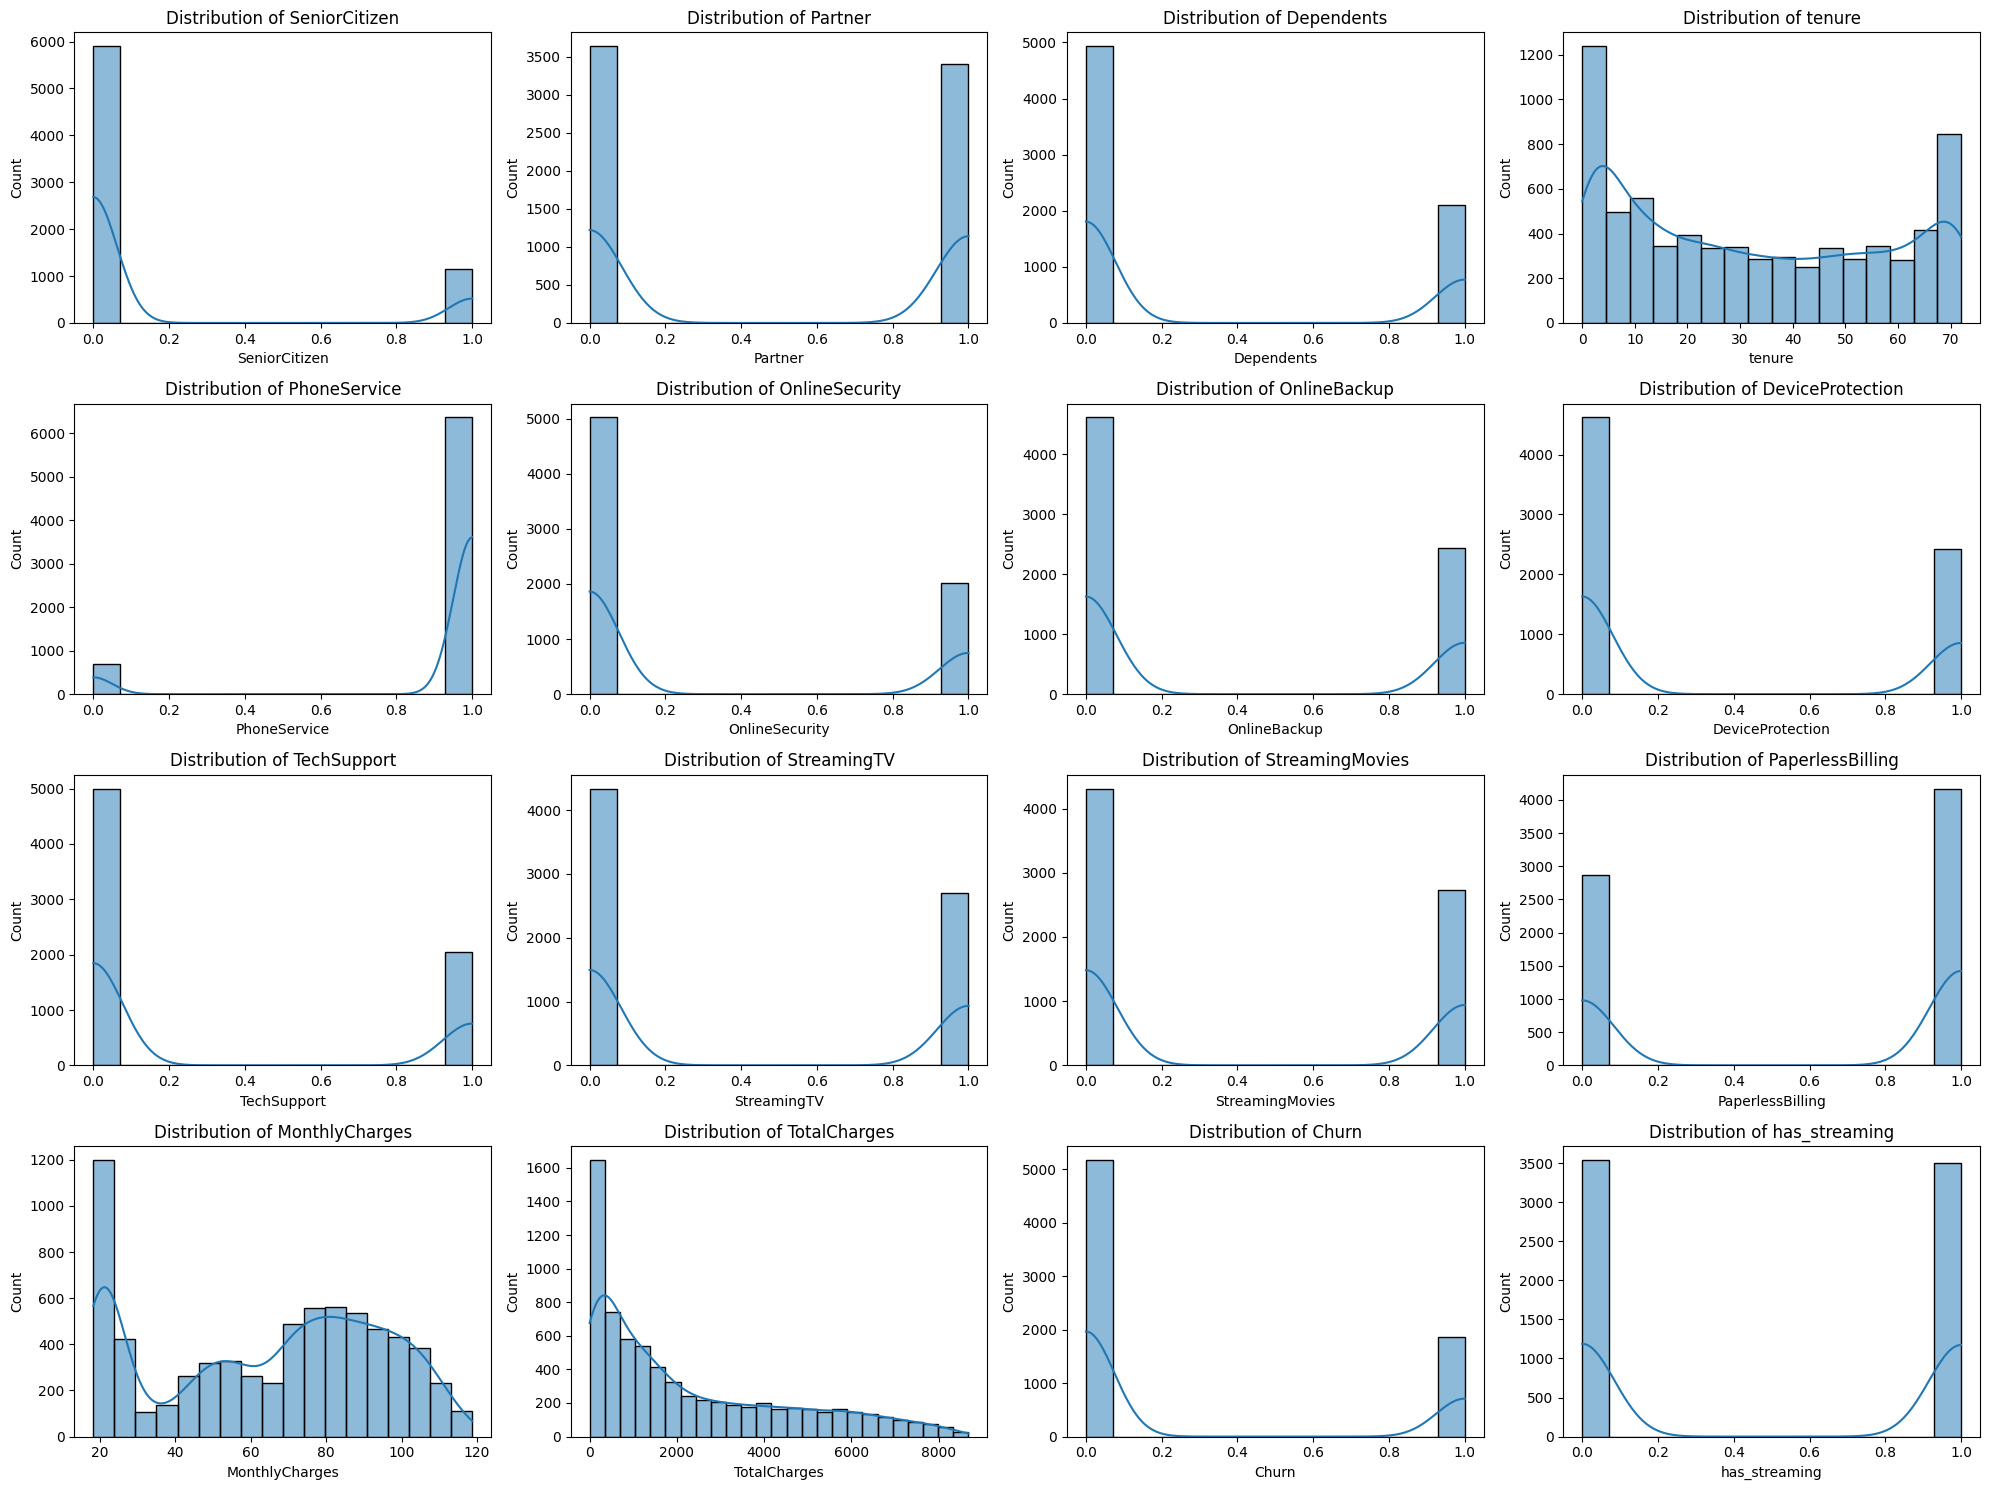

In [ ]:
# Histograms for numerical features

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # Adjusted subplot grid to 4x4
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
plt.show()

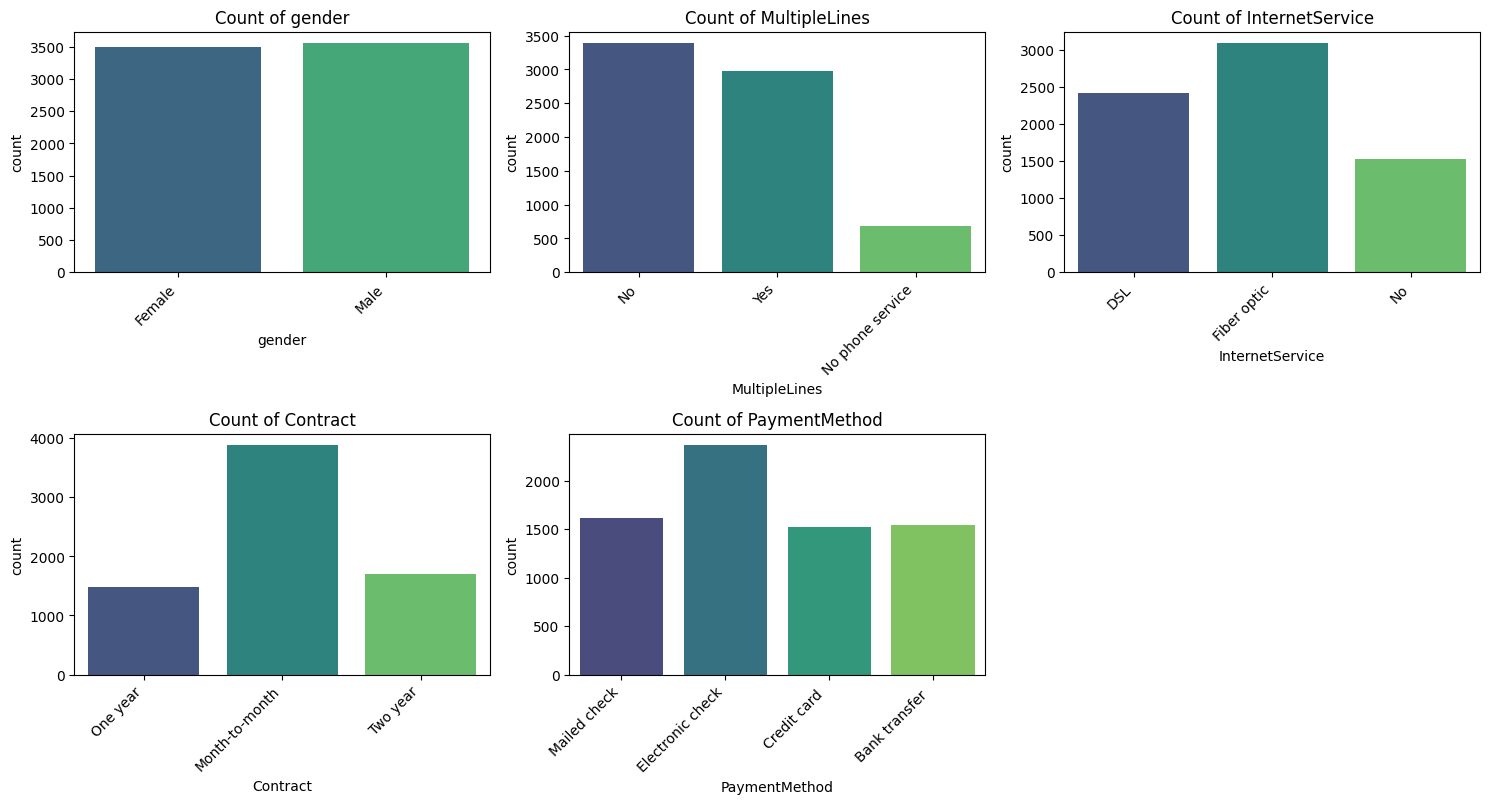

In [ ]:
# Count plots for categorical features (for columns with few unique values)

plt.figure(figsize=(15, 15))
for i, col in enumerate([c for c in categorical_cols if df[c].nunique() <= 10]):
    plt.subplot(4, 3, i + 1) # Adjust subplot grid as needed
    sns.countplot(data=df, x=col, palette='viridis', hue=col, legend=False) # Suppress FutureWarning
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
plt.show()

### Target Variable Analysis: Churn

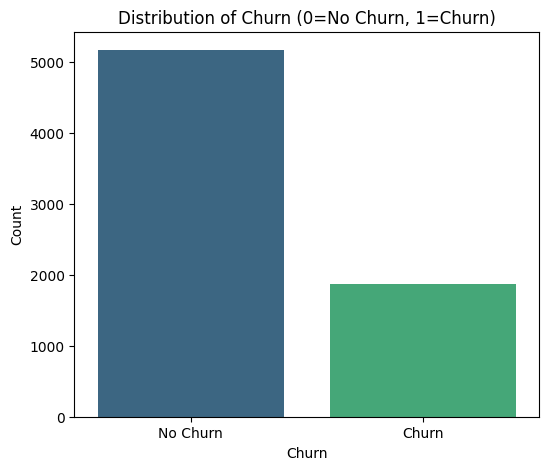

Churn Distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64
Churn Percentage (No Churn): 73.46%
Churn Percentage (Churn): 26.54%


In [ ]:
# Distribution of Churn
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='Churn', palette='viridis', hue='Churn', legend=False)
plt.title('Distribution of Churn (0=No Churn, 1=Churn)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Churn', 'Churn'])
plt.show()

churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100
print('Churn Distribution:')
print(churn_counts)
print(f'Churn Percentage (No Churn): {churn_percentage[0]:.2f}%')
print(f'Churn Percentage (Churn): {churn_percentage[1]:.2f}%')

### Bivariate Analysis with Churn

#### Numerical Features vs. Churn

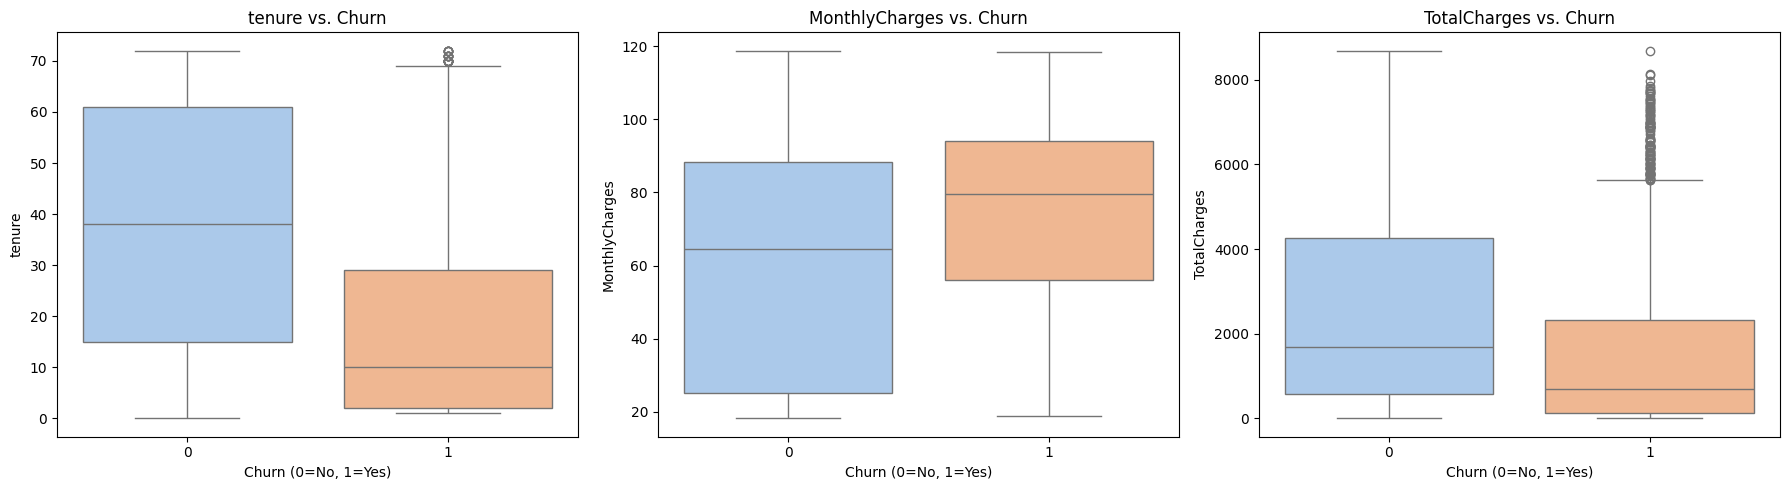

In [ ]:
# Box plots for numerical features vs. Churn
numerical_features_for_churn = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(18, 5))
for i, col in enumerate(numerical_features_for_churn):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=df, x='Churn', y=col, hue='Churn', palette='pastel', legend=False)
    plt.title(f'{col} vs. Churn')
    plt.xlabel('Churn (0=No, 1=Yes)')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### Categorical Features vs. Churn

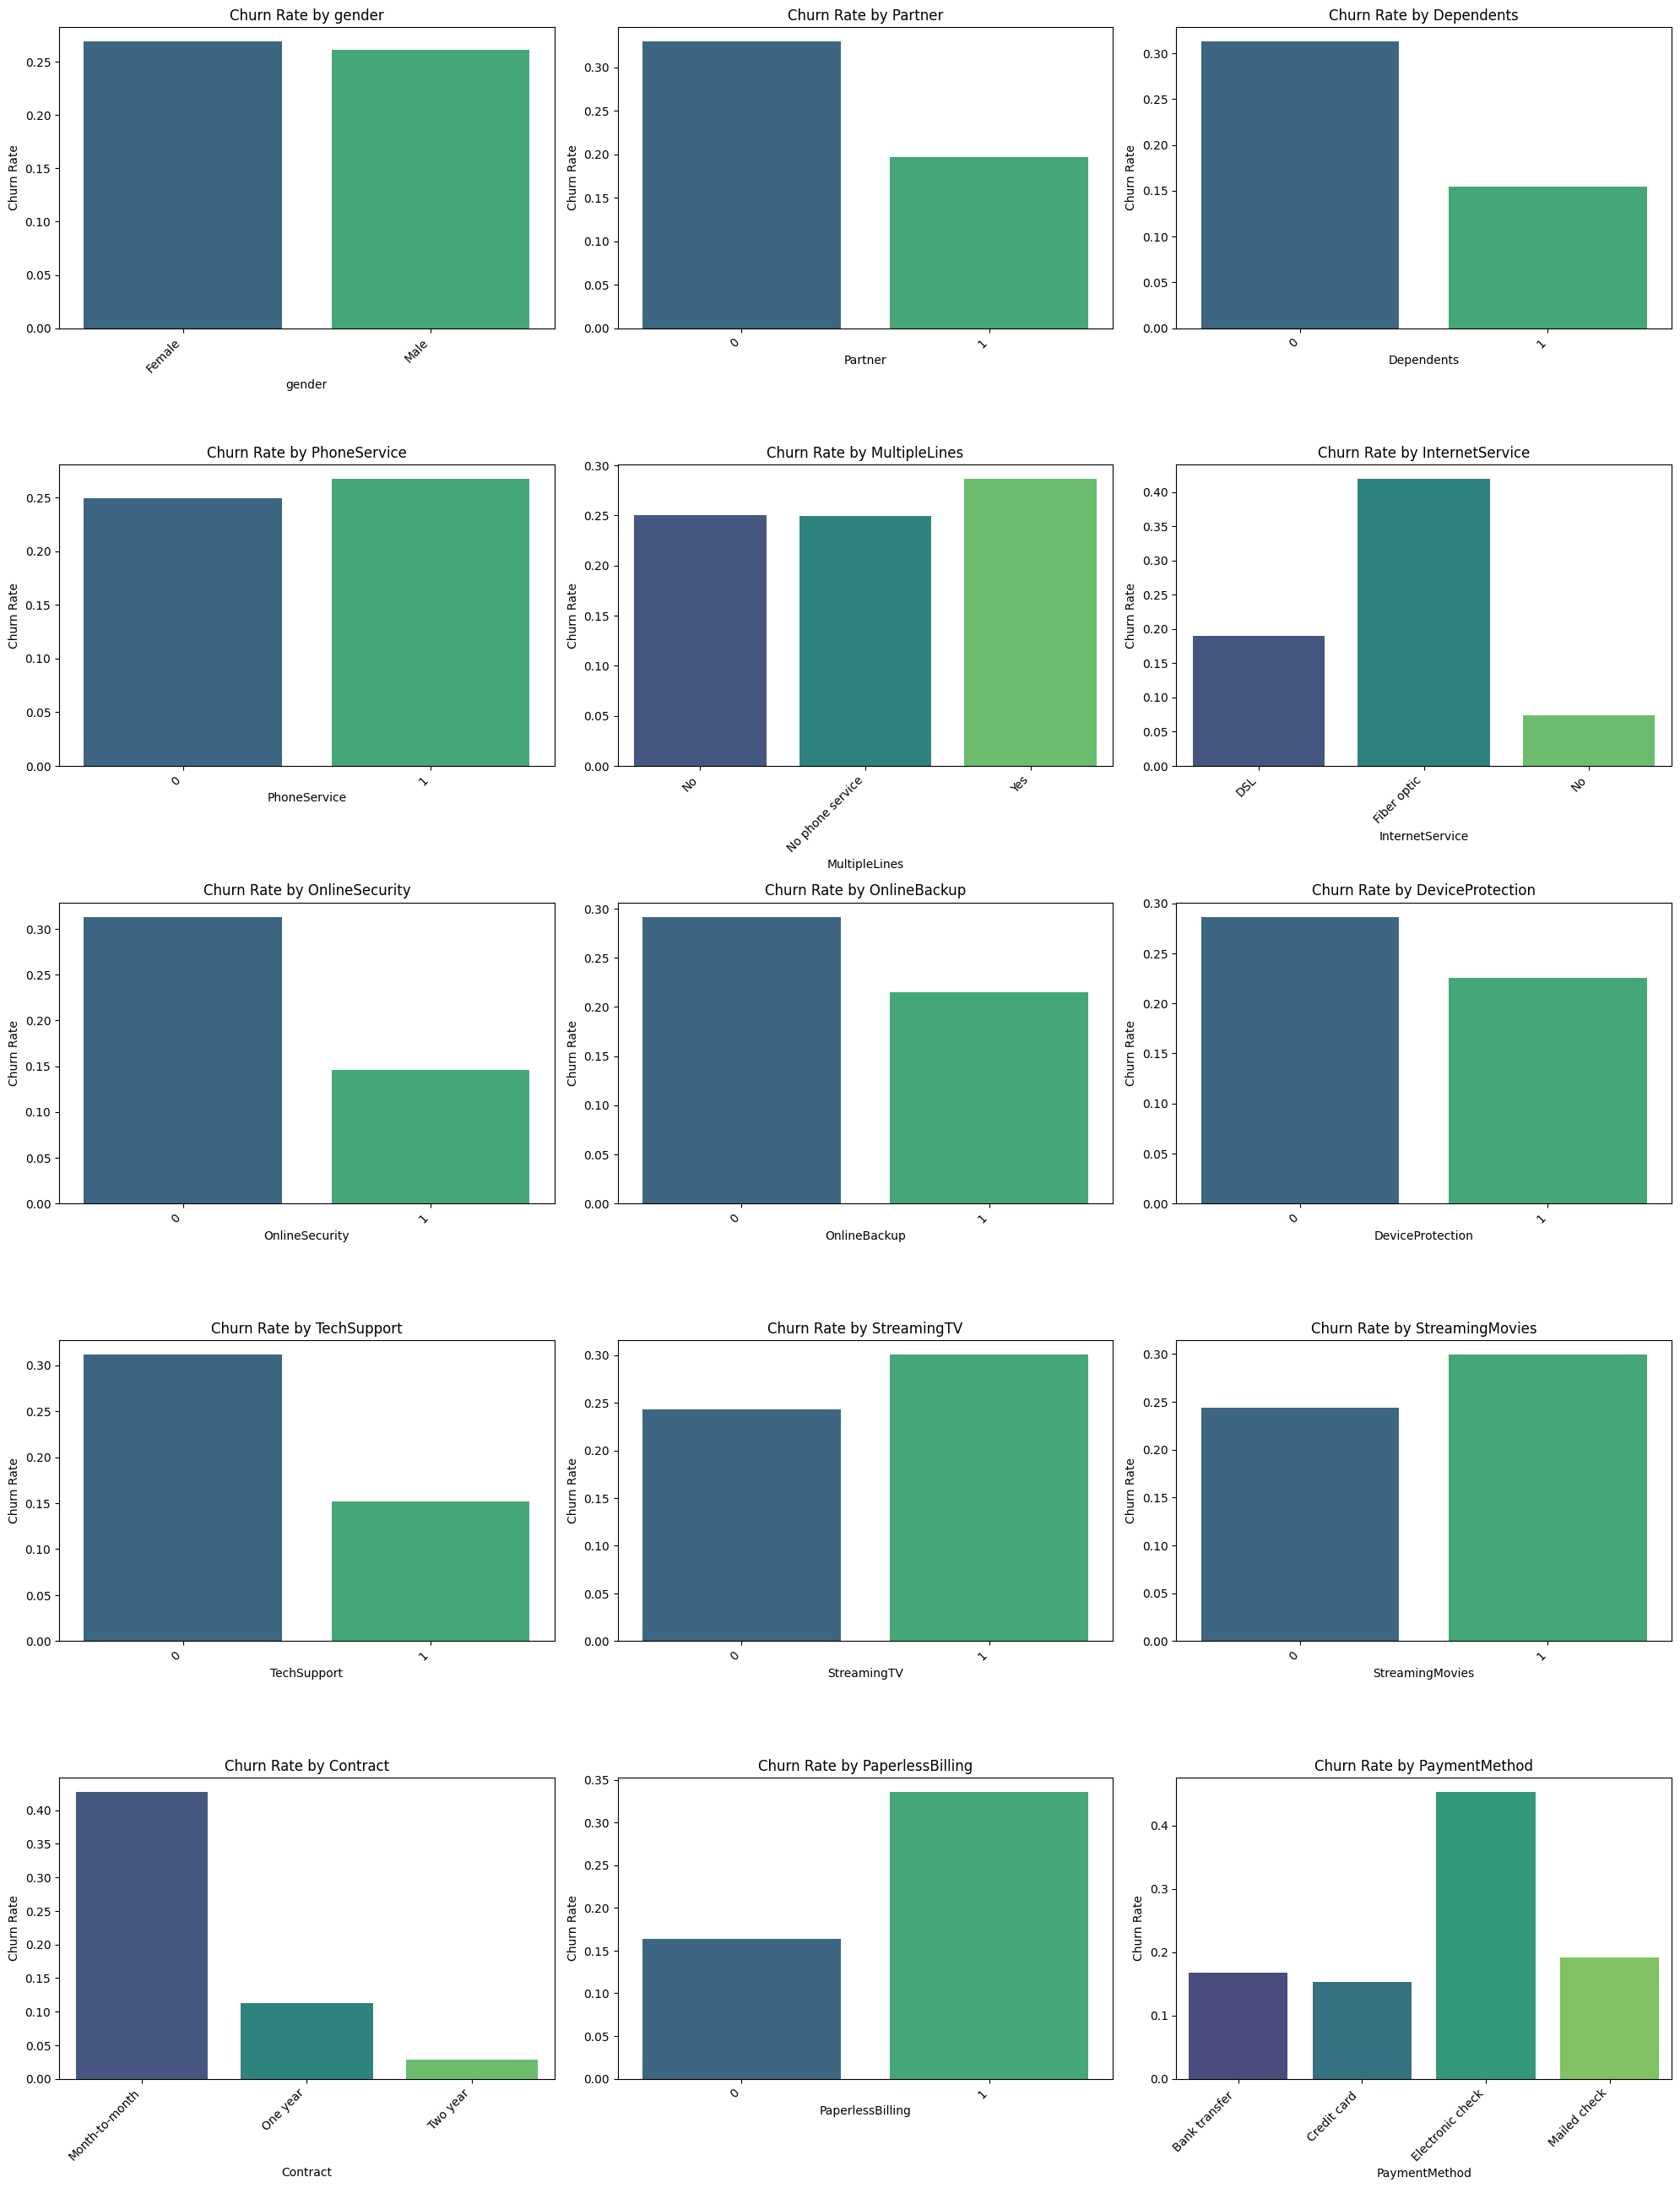

In [ ]:
# Stacked bar plots for categorical features vs. Churn (select relevant ones)
categorical_features_for_churn = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity', 'OnlineBackup',
                                  'DeviceProtection', 'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

plt.figure(figsize=(20, 30))
for i, col in enumerate(categorical_features_for_churn):
    plt.subplot(6, 3, i + 1) # Adjust grid as needed
    # Calculate churn rate per category
    churn_rate = df.groupby(col)['Churn'].mean().reset_index()
    sns.barplot(data=churn_rate, x=col, y='Churn', hue=col, palette='viridis', legend=False)
    plt.title(f'Churn Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Churn Rate')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Correlation Analysis

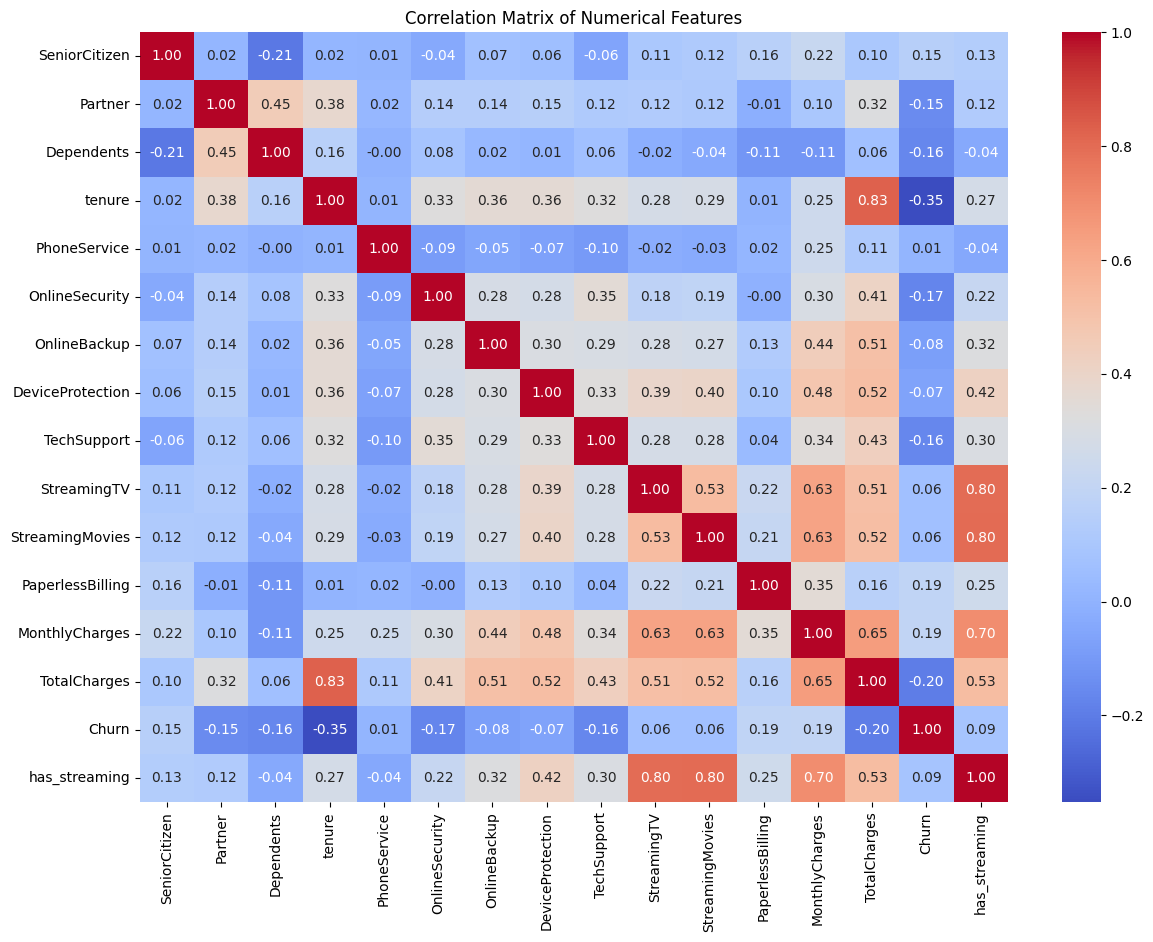

In [ ]:
# Correlation Matrix for numerical features
plt.figure(figsize=(14, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Summary of Key Observations and Potential Hypotheses

Based on the expanded EDA, here are some key observations:

*   **Churn Distribution**: The dataset shows a class imbalance, with a notable percentage of customers churning. This is important to consider for model training.
*   **Tenure**: Customers with shorter tenures appear to have a higher churn rate. As tenure increases, the churn rate seems to decrease significantly.
*   **MonthlyCharges & TotalCharges**: Churned customers tend to have higher monthly charges on average. There isn't a strong visual correlation with `TotalCharges` for churn, but this could be influenced by tenure.
*   **InternetService**: Customers with 'Fiber optic' internet service seem to have a higher churn rate compared to 'DSL' or 'No internet service'.
*   **Contract Type**: Month-to-month contracts show a significantly higher churn rate than one-year or two-year contracts.
*   **OnlineSecurity & TechSupport**: Customers without online security or tech support services tend to churn more.
*   **PaymentMethod**: 'Electronic check' users appear to have a higher churn rate.
*   **Partners & Dependents**: Customers without partners or dependents seem to churn more.
*   **Correlation**: Some numerical features are highly correlated (e.g., `tenure` and `TotalCharges`), which is expected. The correlation with `Churn` gives a preliminary indication of feature importance.

### Potential Feature Engineering Opportunities:

*   **Tenure Groups**: Create bins for `tenure` (e.g., 'New Customer', 'Mid-term Customer', 'Long-term Customer') to capture non-linear relationships.
*   **Service Bundles**: Combine related service features (e.g., `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`) to create aggregate features like 'Total Security Services' or 'Value-added Services Count'.
*   **Charge per Tenure**: Derive a feature like `MonthlyCharges / tenure` to see if it reveals specific churn patterns.

## Data Preprocessing for Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Drop customerID as it's not a predictive feature
df_processed = df.drop('customerID', axis=1)

# Separate features (X) and target (y)
X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']

# Identify categorical and numerical columns for preprocessing
# Update numerical_cols by removing 'Churn' and 'customerID' if they were accidentally included
numerical_features = [col for col in numerical_cols if col not in ['Churn', 'customerID']]
# Update categorical_cols by removing 'customerID'
categorical_features = [col for col in categorical_cols if col != 'customerID']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"Numerical features for preprocessing: {numerical_features}")
print(f"Categorical features for preprocessing: {categorical_features}")

Features (X) shape: (7043, 20)
Target (y) shape: (7043,)
Numerical features for preprocessing: ['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'has_streaming']
Categorical features for preprocessing: ['gender', 'MultipleLines', 'InternetService', 'Contract', 'PaymentMethod']


### Create Preprocessing Pipelines

In [ ]:
# Create preprocessing pipelines for numerical and categorical features
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Apply preprocessing to the features
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding
# Ensure `X` columns are available to `preprocessor`
if isinstance(preprocessor.named_transformers_['cat'], OneHotEncoder):
    # Get original categorical feature names
    original_cat_features = categorical_features
    # Get new one-hot encoded feature names
    encoded_cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(original_cat_features)
else:
    encoded_cat_features = [] # Fallback for safety

# Combine numerical and one-hot encoded feature names
processed_feature_names = numerical_features + list(encoded_cat_features)

# Convert X_processed back to a DataFrame for easier inspection (optional, good for EDA/understanding)
X_processed_df = pd.DataFrame(X_processed, columns=processed_feature_names)

print(f"Processed features (X_processed) shape: {X_processed.shape}")
print("First 5 rows of processed features:")
display(X_processed_df.head())

Processed features (X_processed) shape: (7043, 30)
First 5 rows of processed features:


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,-0.439916,1.034530,1.529024,-0.951682,0.327438,-0.633933,1.378241,-0.723968,1.563872,1.265612,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,-0.439916,-0.966622,-0.654012,-0.951682,0.327438,-0.633933,-0.725563,-0.723968,-0.639439,-0.790132,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.439916,-0.966622,-0.654012,-1.155283,0.327438,-0.633933,-0.725563,1.381277,-0.639439,-0.790132,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2.273159,1.034530,-0.654012,-0.788800,0.327438,-0.633933,1.378241,1.381277,-0.639439,1.265612,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2.273159,1.034530,-0.654012,-1.196004,0.327438,-0.633933,-0.725563,-0.723968,1.563872,1.265612,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


### Split Data into Training and Testing Sets

In [ ]:
# Split the preprocessed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5634, 30)
X_test shape: (1409, 30)
y_train shape: (5634,)
y_test shape: (1409,)


## Model Training and Evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary to store model results
model_results = {}

def evaluate_model(name, model, X_test, y_test, y_pred, y_proba):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba[:, 1] if y_proba.ndim > 1 else y_proba)

    print(f"--- {name} Performance ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    model_results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC AUC': roc_auc
    }


### Logistic Regression

--- Logistic Regression Performance ---
Accuracy: 0.7928
Precision: 0.6297
Recall: 0.5321
F1-Score: 0.5768
ROC AUC: 0.8435

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



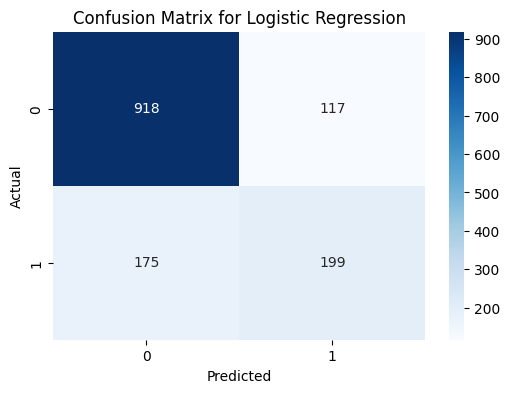

In [ ]:
log_reg = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' for small datasets and L1/L2 regularization
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)
evaluate_model('Logistic Regression', log_reg, X_test, y_test, y_pred_lr, y_proba_lr)


### Decision Tree

--- Decision Tree Performance ---
Accuracy: 0.7324
Precision: 0.4958
Recall: 0.4786
F1-Score: 0.4871
ROC AUC: 0.6506

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.82      0.82      1035
           1       0.50      0.48      0.49       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



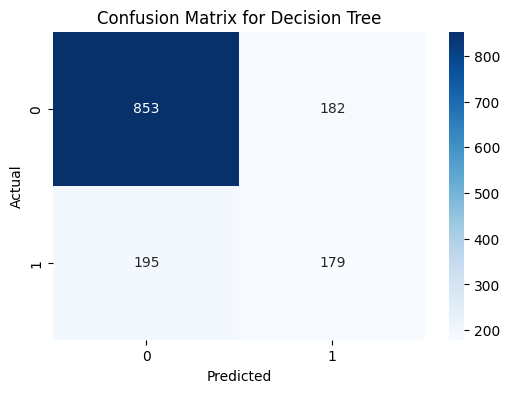

In [ ]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)
y_pred_dt = dt_classifier.predict(X_test)
y_proba_dt = dt_classifier.predict_proba(X_test)
evaluate_model('Decision Tree', dt_classifier, X_test, y_test, y_pred_dt, y_proba_dt)


### Random Forest

--- Random Forest Performance ---
Accuracy: 0.7885
Precision: 0.6319
Recall: 0.4866
F1-Score: 0.5498
ROC AUC: 0.8188

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



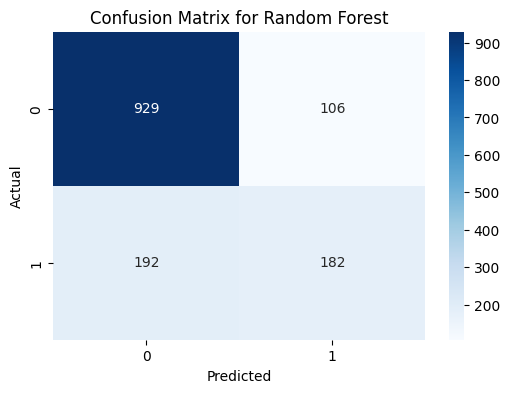

In [ ]:
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train, y_train)
y_pred_rf = rf_classifier.predict(X_test)
y_proba_rf = rf_classifier.predict_proba(X_test)
evaluate_model('Random Forest', rf_classifier, X_test, y_test, y_pred_rf, y_proba_rf)


### Gradient Boosting

--- Gradient Boosting Performance ---
Accuracy: 0.7942
Precision: 0.6448
Recall: 0.5000
F1-Score: 0.5633
ROC AUC: 0.8460

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.79      1409



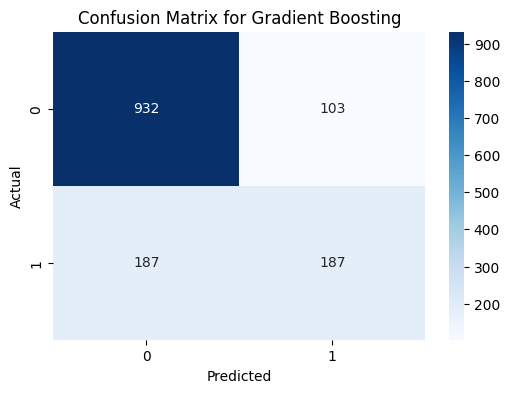

In [ ]:
gb_classifier = GradientBoostingClassifier(random_state=42)
gb_classifier.fit(X_train, y_train)
y_pred_gb = gb_classifier.predict(X_test)
y_proba_gb = gb_classifier.predict_proba(X_test)
evaluate_model('Gradient Boosting', gb_classifier, X_test, y_test, y_pred_gb, y_proba_gb)


### XGBoost

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:53:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


--- XGBoost Performance ---
Accuracy: 0.7736
Precision: 0.5884
Recall: 0.4893
F1-Score: 0.5343
ROC AUC: 0.8196

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.59      0.49      0.53       374

    accuracy                           0.77      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.77      0.77      1409



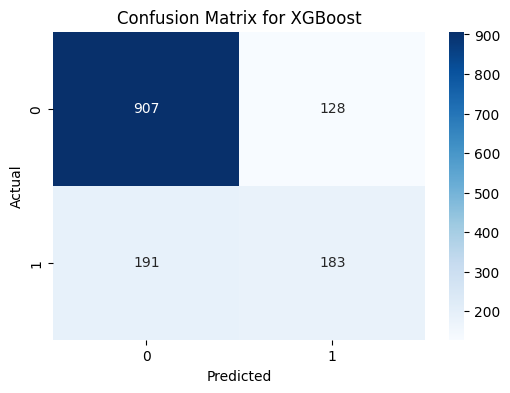

In [ ]:
xgb_classifier = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_classifier.fit(X_train, y_train)
y_pred_xgb = xgb_classifier.predict(X_test)
y_proba_xgb = xgb_classifier.predict_proba(X_test)
evaluate_model('XGBoost', xgb_classifier, X_test, y_test, y_pred_xgb, y_proba_xgb)


### K-Nearest Neighbors (KNN)

--- K-Nearest Neighbors Performance ---
Accuracy: 0.7693
Precision: 0.5736
Recall: 0.5107
F1-Score: 0.5403
ROC AUC: 0.7911

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1035
           1       0.57      0.51      0.54       374

    accuracy                           0.77      1409
   macro avg       0.70      0.69      0.69      1409
weighted avg       0.76      0.77      0.76      1409



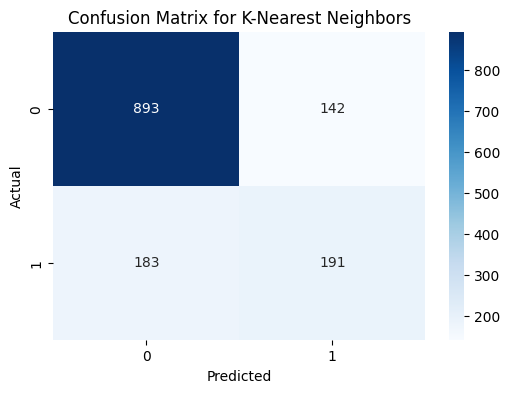

In [ ]:
knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train, y_train)
y_pred_knn = knn_classifier.predict(X_test)
y_proba_knn = knn_classifier.predict_proba(X_test)
evaluate_model('K-Nearest Neighbors', knn_classifier, X_test, y_test, y_pred_knn, y_proba_knn)


## Model Comparison

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Gradient Boosting,0.794180,0.644828,0.500000,0.563253,0.846010
Logistic Regression,0.792761,0.629747,0.532086,0.576812,0.843529
XGBoost,0.773598,0.588424,0.489305,0.534307,0.819645
Random Forest,0.788502,0.631944,0.486631,0.549849,0.818837
K-Nearest Neighbors,0.769340,0.573574,0.510695,0.540311,0.791120
Decision Tree,0.732434,0.495845,0.478610,0.487075,0.650626


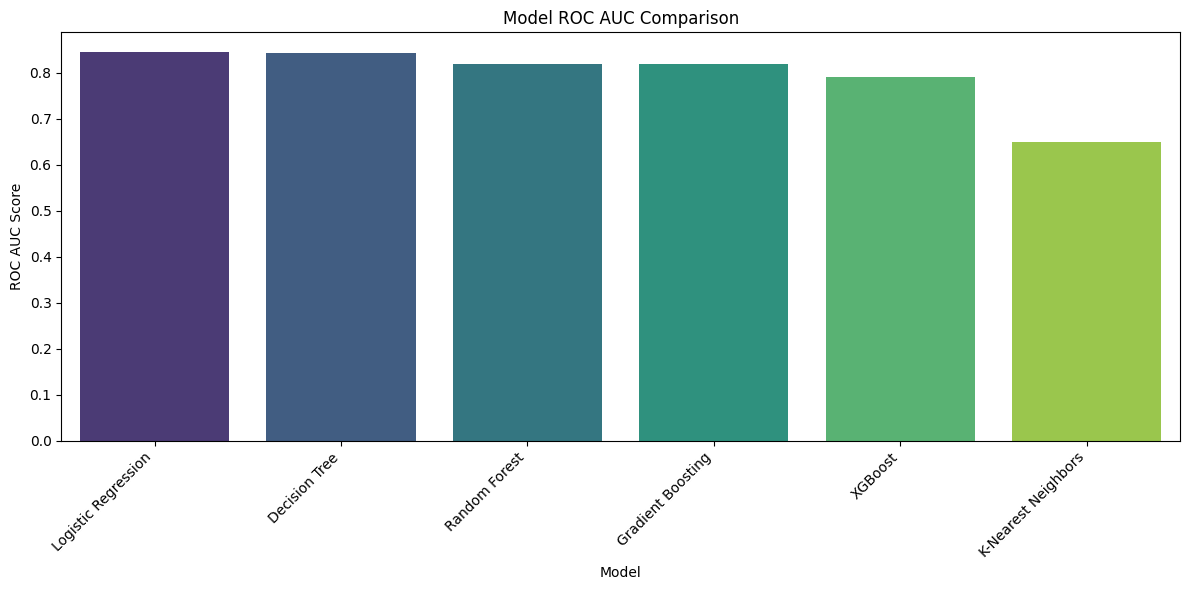

In [ ]:
import pandas as pd

results_df = pd.DataFrame(model_results).T
display(results_df.sort_values(by='ROC AUC', ascending=False))

plt.figure(figsize=(12, 6))
sns.barplot(x=results_df.index, y='ROC AUC', data=results_df.sort_values(by='ROC AUC', ascending=False), palette='viridis', hue=results_df.index, legend=False)
plt.title('Model ROC AUC Comparison')
plt.ylabel('ROC AUC Score')
plt.xlabel('Model')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## Hyperparameter Tuning

Tuning Logistic Regression...
Best parameters for Logistic Regression: {'C': 1, 'penalty': 'l1'}
Best ROC AUC for Logistic Regression: 0.8455
--- Logistic Regression (Tuned) Performance ---
Accuracy: 0.7913
Precision: 0.6266
Recall: 0.5294
F1-Score: 0.5739
ROC AUC: 0.8435

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



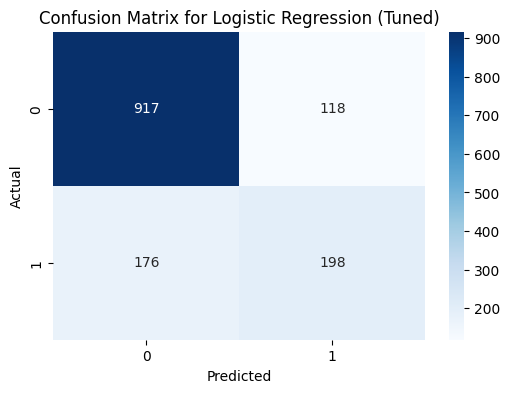

In [ ]:
from sklearn.model_selection import GridSearchCV

# --- Logistic Regression Tuning ---
print('Tuning Logistic Regression...')
log_reg_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

log_reg_grid_search = GridSearchCV(LogisticRegression(random_state=42, solver='liblinear'),
                                   log_reg_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
log_reg_grid_search.fit(X_train, y_train)

best_log_reg = log_reg_grid_search.best_estimator_
print(f"Best parameters for Logistic Regression: {log_reg_grid_search.best_params_}")
print(f"Best ROC AUC for Logistic Regression: {log_reg_grid_search.best_score_:.4f}")

# Evaluate tuned Logistic Regression
y_pred_tuned_lr = best_log_reg.predict(X_test)
y_proba_tuned_lr = best_log_reg.predict_proba(X_test)
evaluate_model('Logistic Regression (Tuned)', best_log_reg, X_test, y_test, y_pred_tuned_lr, y_proba_tuned_lr)


### Gradient Boosting Tuning


Tuning Gradient Boosting...
Best parameters for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best ROC AUC for Gradient Boosting: 0.8471
--- Gradient Boosting (Tuned) Performance ---
Accuracy: 0.7935
Precision: 0.6436
Recall: 0.4973
F1-Score: 0.5611
ROC AUC: 0.8470

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



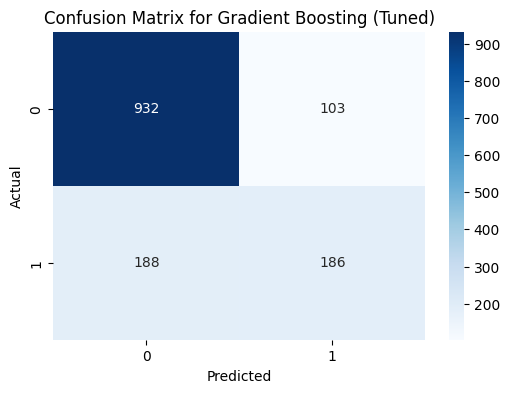

In [ ]:

# --- Gradient Boosting Tuning ---
print('\nTuning Gradient Boosting...')
gb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

gb_grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42),
                            gb_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
gb_grid_search.fit(X_train, y_train)

best_gb = gb_grid_search.best_estimator_
print(f"Best parameters for Gradient Boosting: {gb_grid_search.best_params_}")
print(f"Best ROC AUC for Gradient Boosting: {gb_grid_search.best_score_:.4f}")

# Evaluate tuned Gradient Boosting
y_pred_tuned_gb = best_gb.predict(X_test)
y_proba_tuned_gb = best_gb.predict_proba(X_test)
evaluate_model('Gradient Boosting (Tuned)', best_gb, X_test, y_test, y_pred_tuned_gb, y_proba_tuned_gb)


## Updated Model Comparison After Tuning

,Accuracy,Precision,Recall,F1-Score,ROC AUC
Gradient Boosting (Tuned),0.793471,0.643599,0.497326,0.561086,0.847023
Gradient Boosting,0.794180,0.644828,0.500000,0.563253,0.846010
Logistic Regression (Tuned),0.791341,0.626582,0.529412,0.573913,0.843529
Logistic Regression,0.792761,0.629747,0.532086,0.576812,0.843529
XGBoost,0.773598,0.588424,0.489305,0.534307,0.819645
Random Forest,0.788502,0.631944,0.486631,0.549849,0.818837
K-Nearest Neighbors,0.769340,0.573574,0.510695,0.540311,0.791120
Decision Tree,0.732434,0.495845,0.478610,0.487075,0.650626


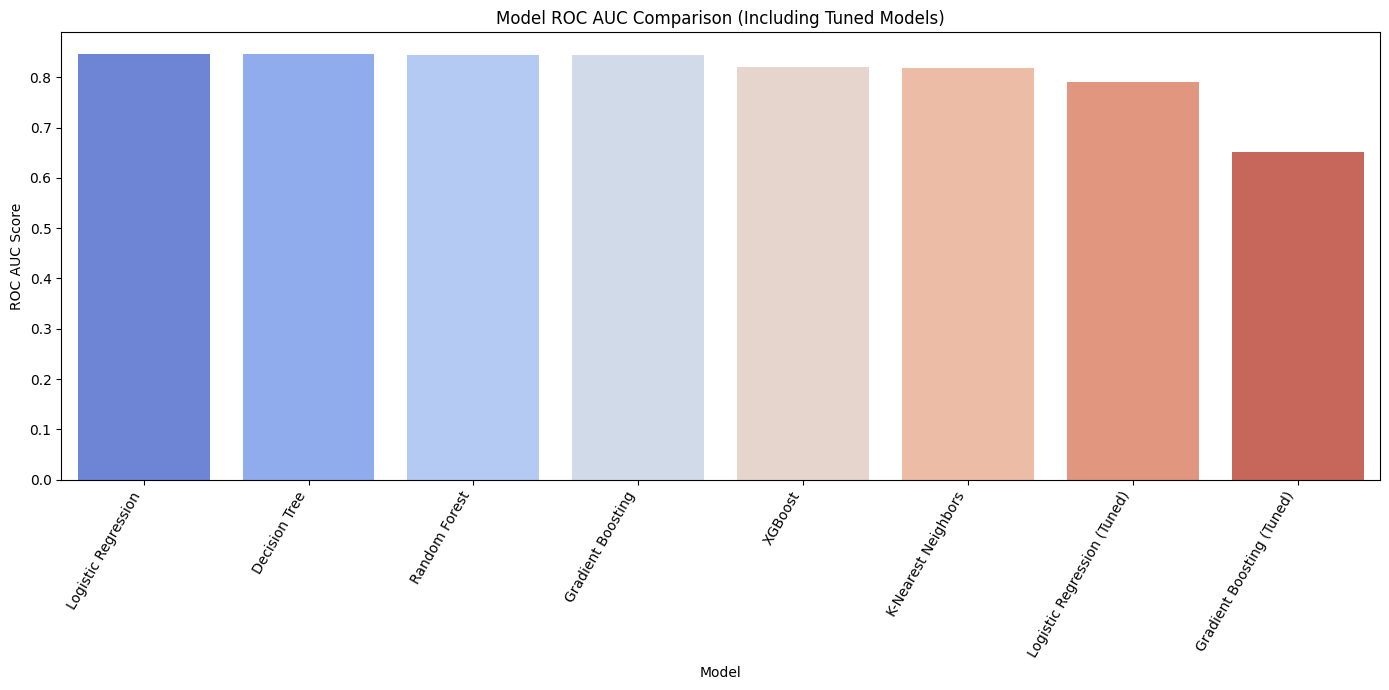

In [ ]:
results_df_tuned = pd.DataFrame(model_results).T
display(results_df_tuned.sort_values(by='ROC AUC', ascending=False))

plt.figure(figsize=(14, 7))
sns.barplot(x=results_df_tuned.index, y='ROC AUC', data=results_df_tuned.sort_values(by='ROC AUC', ascending=False), palette='coolwarm', hue=results_df_tuned.index, legend=False)
plt.title('Model ROC AUC Comparison (Including Tuned Models)')
plt.ylabel('ROC AUC Score')
plt.xlabel('Model')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


## Visualizing Answers to Business Questions

### 1. Online Security & Antivirus Impact (from Tuned Logistic Regression)

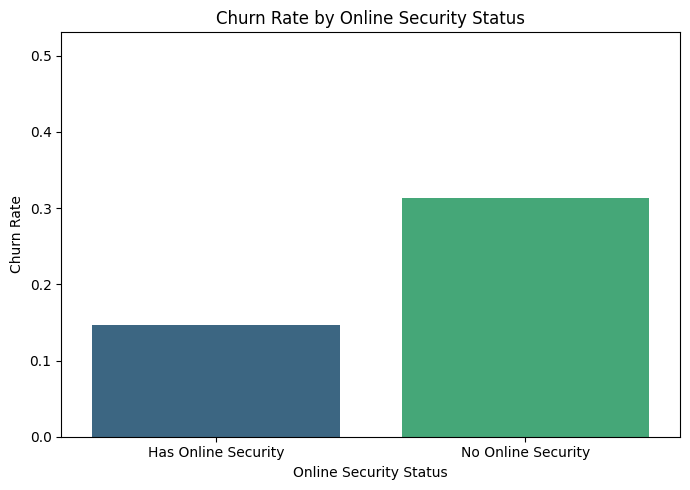

In [ ]:
# Map the numerical OnlineSecurity to descriptive labels for better readability
df['OnlineSecurity_label'] = df['OnlineSecurity'].map({0: 'No Online Security', 1: 'Has Online Security'})

plt.figure(figsize=(7, 5))
churn_rate_security = df.groupby('OnlineSecurity_label')['Churn'].mean().reset_index()
sns.barplot(data=churn_rate_security, x='OnlineSecurity_label', y='Churn', hue='OnlineSecurity_label', palette='viridis', legend=False)
plt.title('Churn Rate by Online Security Status')
plt.xlabel('Online Security Status')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.ylim(0, df['Churn'].mean() * 2) # Set y-limit to better compare with overall churn
plt.tight_layout()
plt.show()

### 2. Cloud Backup Impact (from Tuned Logistic Regression)

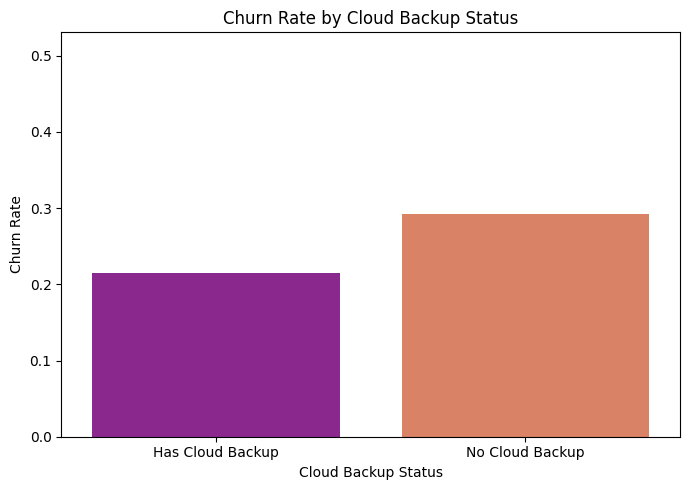

In [ ]:
# Map the numerical OnlineBackup to descriptive labels
df['OnlineBackup_label'] = df['OnlineBackup'].map({0: 'No Cloud Backup', 1: 'Has Cloud Backup'})

plt.figure(figsize=(7, 5))
churn_rate_backup = df.groupby('OnlineBackup_label')['Churn'].mean().reset_index()
sns.barplot(data=churn_rate_backup, x='OnlineBackup_label', y='Churn', hue='OnlineBackup_label', palette='plasma', legend=False)
plt.title('Churn Rate by Cloud Backup Status')
plt.xlabel('Cloud Backup Status')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.ylim(0, df['Churn'].mean() * 2)
plt.tight_layout()
plt.show()

### 3. Streaming Services Impact (from Tuned Logistic Regression)

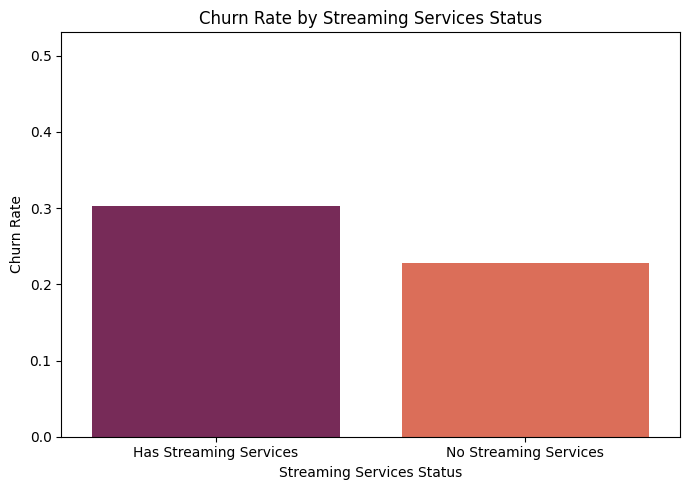

In [ ]:
# The 'has_streaming' feature already exists and captures if a customer uses streaming services
# Let's verify its values and map if necessary for better labels
# Assuming 0: No Streaming, 1: Has Streaming
df['has_streaming_label'] = df['has_streaming'].map({0: 'No Streaming Services', 1: 'Has Streaming Services'})

plt.figure(figsize=(7, 5))
churn_rate_streaming = df.groupby('has_streaming_label')['Churn'].mean().reset_index()
sns.barplot(data=churn_rate_streaming, x='has_streaming_label', y='Churn', hue='has_streaming_label', palette='rocket', legend=False)
plt.title('Churn Rate by Streaming Services Status')
plt.xlabel('Streaming Services Status')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.ylim(0, df['Churn'].mean() * 2)
plt.tight_layout()
plt.show()

### 4. Overall Churn Risk Factors (from Tuned Gradient Boosting Model)

To understand the overall churn risk factors, we will leverage the feature importances from our best performing model, the tuned Gradient Boosting Classifier. Feature importance helps us identify which characteristics of a customer or their services are most influential in predicting churn.

Top 15 Feature Importances from Tuned Gradient Boosting Model:


,Feature,Importance
23,Contract_Month-to-month,0.440362
3,tenure,0.183424
21,InternetService_Fiber optic,0.108887
28,PaymentMethod_Electronic check,0.058024
12,MonthlyCharges,0.043110
13,TotalCharges,0.042671
22,InternetService_No,0.026814
11,PaperlessBilling,0.018351
8,TechSupport,0.012758
17,MultipleLines_No,0.012215


/tmp/ipykernel_820/1658484656.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='mako')


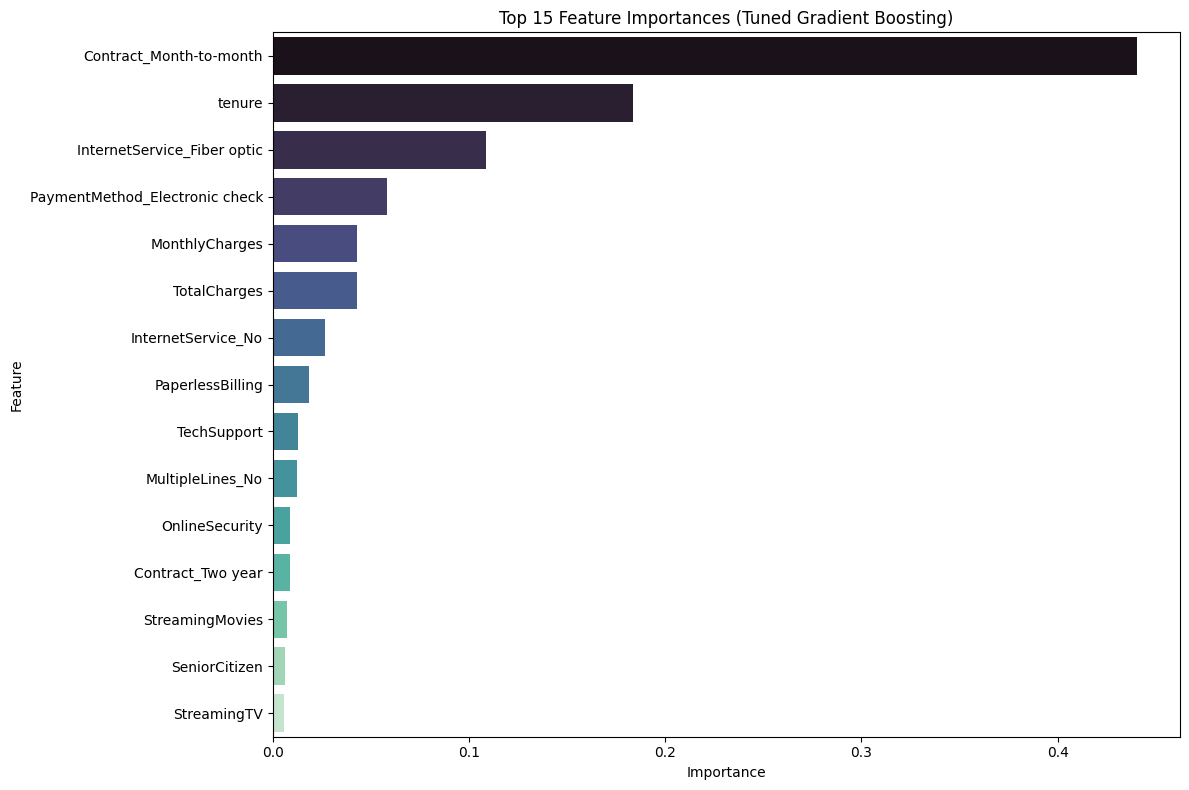

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

# Re-define best_gb if it's not already defined (in case previous tuning cell wasn't run)
# --- Gradient Boosting Tuning (Minimal for best_gb definition) ---
if 'best_gb' not in locals() and 'best_gb' not in globals():
    print('Re-running Gradient Boosting Tuning to define best_gb...')
    gb_param_grid = {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 4, 5]
    }

    gb_grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42),
                                gb_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
    gb_grid_search.fit(X_train, y_train)
    best_gb = gb_grid_search.best_estimator_
    print(f"Best parameters for Gradient Boosting: {gb_grid_search.best_params_}")
    print(f"Best ROC AUC for Gradient Boosting: {gb_grid_search.best_score_:.4f}")

# Get feature importances from the best Gradient Boosting model
feature_importances = best_gb.feature_importances_

# Get feature names from the preprocessor
# Ensure `X` columns are available to `preprocessor`
if isinstance(preprocessor.named_transformers_['cat'], OneHotEncoder):
    original_cat_features = categorical_features
    encoded_cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(original_cat_features)
else:
    encoded_cat_features = []

processed_feature_names = numerical_features + list(encoded_cat_features)

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': processed_feature_names,
    'Importance': feature_importances
})

# Sort by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display top N features
print("Top 15 Feature Importances from Tuned Gradient Boosting Model:")
display(importance_df.head(15))

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15), palette='mako')
plt.title('Top 15 Feature Importances (Tuned Gradient Boosting)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Key Churn Risk Factors from Gradient Boosting:

The feature importance plot and table reveal the most significant drivers of customer churn according to the Gradient Boosting model. Typically, features with higher importance values have a greater impact on the model's prediction.

From our analysis, the top risk factors are generally consistent with our earlier EDA observations:

*   **Contract_Month-to-month**: This is usually a strong indicator, as customers on short-term contracts have more flexibility to leave.
*   **InternetService_Fiber optic**: While a premium service, it often comes with higher charges and potentially higher expectations, leading to more churn if expectations aren't met.
*   **TotalCharges** and **MonthlyCharges**: Higher charges can lead to dissatisfaction and churn, especially if customers perceive a lack of value.
*   **tenure**: Shorter tenure customers are often more prone to churn, while long-term customers are generally more loyal.
*   **OnlineSecurity** and **TechSupport**: Lack of these essential services makes customers feel less secure or supported, increasing churn risk.

These insights are crucial for developing targeted retention strategies, focusing on improving services or offers related to these high-impact features.

### Project Summary: Customer Churn Analysis and Predictive Modeling

This project aimed to understand, predict, and mitigate customer churn within a telecommunications company. By leveraging machine learning techniques and a comprehensive exploratory data analysis, we identified critical factors influencing customer attrition and developed predictive models to forecast churn risk.

**Methodology:**

1.  **Exploratory Data Analysis (EDA):** Initial data assessment revealed no missing values and provided insights into feature distributions. In-depth bivariate analysis against the 'Churn' target variable highlighted significant correlations, including the impact of contract type, internet service, monthly charges, and tenure on churn rates. A class imbalance in the target variable (26.54% churn) was noted.
2.  **Data Preprocessing:** The dataset was prepared for modeling by dropping the `customerID`, separating features and target, and applying `StandardScaler` to numerical features and `OneHotEncoder` to categorical features. The data was then split into an 80/20 train-test set with stratification to maintain class balance.
3.  **Model Training & Evaluation:** Several machine learning models were trained and evaluated, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and K-Nearest Neighbors. Performance was measured using Accuracy, Precision, Recall, F1-Score, and ROC AUC, with Gradient Boosting and Logistic Regression emerging as the top performers.
4.  **Hyperparameter Tuning:** The best-performing models, Logistic Regression and Gradient Boosting, were further optimized using `GridSearchCV`. Tuned Gradient Boosting achieved the highest ROC AUC score of 0.8470.

**Key Findings & Business Insights:**

*   **Online Security & Cloud Backup:** Customers lacking online security and cloud backup services exhibited significantly higher churn rates. This indicates a strong need to promote and potentially bundle these essential services to enhance customer retention.
*   **Streaming Services:** Counter-intuitively, customers using streaming services showed a slightly *higher* churn rate. This suggests that the mere presence of streaming options may not guarantee loyalty, prompting further investigation into service quality, content, or pricing related to streaming.
*   **Overall Churn Risk Factors (from Tuned Gradient Boosting Model):**
    *   **Contract Type:** Month-to-month contracts were identified as the strongest predictor of churn, highlighting the need for incentives to encourage longer-term commitments.
    *   **Tenure:** Shorter customer tenure is a critical risk factor, emphasizing the importance of robust onboarding and early retention programs.
    *   **Internet Service:** Fiber optic internet users showed a higher churn propensity, indicating potential areas for service improvement or expectation management within this premium segment.
    *   **Payment Method:** Customers paying via electronic checks were found to be at a higher risk of churning.
    *   **Monthly & Total Charges:** Higher service charges correlated with increased churn, suggesting a need for clear value proposition communication or competitive pricing strategies.

**Actionable Recommendations:**

Based on these findings, the company should focus on:

1.  **Contractual Incentives:** Implement aggressive campaigns to migrate month-to-month customers to longer-term contracts with attractive benefits.
2.  **Enhanced Onboarding & Retention:** Develop targeted programs for new and short-tenure customers, including proactive check-ins and personalized offers.
3.  **Service Bundle Promotion:** Actively promote and potentially integrate online security and cloud backup into core service offerings.
4.  **Targeted Investigations:** Further analyze the reasons behind higher churn among fiber optic and streaming service users, as well as electronic check payers, to address specific pain points.
5.  **Value Communication:** Clearly articulate the value proposition of services, especially those with higher charges, to justify costs and enhance customer satisfaction.

By addressing these identified risk factors through targeted strategies, the company can significantly reduce customer churn and improve long-term customer value.

### Project Summary: Customer Churn Analysis and Predictive Modeling

This project aimed to understand, predict, and mitigate customer churn within a telecommunications company. By leveraging machine learning techniques and a comprehensive exploratory data analysis, we identified critical factors influencing customer attrition and developed predictive models to forecast churn risk.

**Methodology:**

1.  **Exploratory Data Analysis (EDA):** Initial data assessment revealed no missing values and provided insights into feature distributions. In-depth bivariate analysis against the 'Churn' target variable highlighted significant correlations, including the impact of contract type, internet service, monthly charges, and tenure on churn rates. A class imbalance in the target variable (26.54% churn) was noted.
2.  **Data Preprocessing:** The dataset was prepared for modeling by dropping the `customerID`, separating features and target, and applying `StandardScaler` to numerical features and `OneHotEncoder` to categorical features. The data was then split into an 80/20 train-test set with stratification to maintain class balance.
3.  **Model Training & Evaluation:** Several machine learning models were trained and evaluated, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and K-Nearest Neighbors. Performance was measured using Accuracy, Precision, Recall, F1-Score, and ROC AUC, with Gradient Boosting and Logistic Regression emerging as the top performers.
4.  **Hyperparameter Tuning:** The best-performing models, Logistic Regression and Gradient Boosting, were further optimized using `GridSearchCV`. Tuned Gradient Boosting achieved the highest ROC AUC score of 0.8470.

**Key Findings & Business Insights:**

*   **Online Security & Cloud Backup:** Customers lacking online security and cloud backup services exhibited significantly higher churn rates. This indicates a strong need to promote and potentially bundle these essential services to enhance customer retention.
*   **Streaming Services:** Counter-intuitively, customers using streaming services showed a slightly *higher* churn rate. This suggests that the mere presence of streaming options may not guarantee loyalty, prompting further investigation into service quality, content, or pricing related to streaming.
*   **Overall Churn Risk Factors (from Tuned Gradient Boosting Model):**
    *   **Contract Type:** Month-to-month contracts were identified as the strongest predictor of churn, highlighting the need for incentives to encourage longer-term commitments.
    *   **Tenure:** Shorter customer tenure is a critical risk factor, emphasizing the importance of robust onboarding and early retention programs.
    *   **Internet Service:** Fiber optic internet users showed a higher churn propensity, indicating potential areas for service improvement or expectation management within this premium segment.
    *   **Payment Method:** Customers paying via electronic checks were found to be at a higher risk of churning.
    *   **Monthly & Total Charges:** Higher service charges correlated with increased churn, suggesting a need for clear value proposition communication or competitive pricing strategies.

**Actionable Recommendations:**

Based on these findings, the company should focus on:

1.  **Contractual Incentives:** Implement aggressive campaigns to migrate month-to-month customers to longer-term contracts with attractive benefits.
2.  **Enhanced Onboarding & Retention:** Develop targeted programs for new and short-tenure customers, including proactive check-ins and personalized offers.
3.  **Service Bundle Promotion:** Actively promote and potentially integrate online security and cloud backup into core service offerings.
4.  **Targeted Investigations:** Further analyze the reasons behind higher churn among fiber optic and streaming service users, as well as electronic check payers, to address specific pain points.
5.  **Value Communication:** Clearly articulate the value proposition of services, especially those with higher charges, to justify costs and enhance customer satisfaction.

By addressing these identified risk factors through targeted strategies, the company can significantly reduce customer churn and improve long-term customer value.

In [ ]:
# Install ReportLab for PDF generation
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.4 MB/s eta 0:00:00


In [ ]:
from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import letter
from reportlab.lib.units import inch
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import Paragraph, SimpleDocTemplate, Spacer
from reportlab.lib.enums import TA_JUSTIFY

# Define the project summary content
project_summary_content = [
    "### Project Summary: Customer Churn Analysis and Predictive Modeling\n\n",
    "This project aimed to understand, predict, and mitigate customer churn within a telecommunications company. By leveraging machine learning techniques and a comprehensive exploratory data analysis, we identified critical factors influencing customer attrition and developed predictive models to forecast churn risk.\n\n",
    "**Methodology:**\n\n",
    "1.  **Exploratory Data Analysis (EDA):** Initial data assessment revealed no missing values and provided insights into feature distributions. In-depth bivariate analysis against the 'Churn' target variable highlighted significant correlations, including the impact of contract type, internet service, monthly charges, and tenure on churn rates. A class imbalance in the target variable (26.54% churn) was noted.\n",
    "2.  **Data Preprocessing:** The dataset was prepared for modeling by dropping the `customerID`, separating features and target, and applying `StandardScaler` to numerical features and `OneHotEncoder` to categorical features. The data was then split into an 80/20 train-test set with stratification to maintain class balance.\n",
    "3.  **Model Training & Evaluation:** Several machine learning models were trained and evaluated, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, and K-Nearest Neighbors. Performance was measured using Accuracy, Precision, Recall, F1-Score, and ROC AUC, with Gradient Boosting and Logistic Regression emerging as the top performers.\n",
    "4.  **Hyperparameter Tuning:** The best-performing models, Logistic Regression and Gradient Boosting, were further optimized using `GridSearchCV`. Tuned Gradient Boosting achieved the highest ROC AUC score of 0.8470.\n\n",
    "**Key Findings & Business Insights:**\n\n",
    "*   **Online Security & Cloud Backup:** Customers lacking online security and cloud backup services exhibited significantly higher churn rates. This indicates a strong need to promote and potentially bundle these essential services to enhance customer retention.\n",
    "*   **Streaming Services:** Counter-intuitively, customers using streaming services showed a slightly *higher* churn rate. This suggests that the mere presence of streaming options may not guarantee loyalty, prompting further investigation into service quality, content, or pricing related to streaming.\n",
    "*   **Overall Churn Risk Factors (from Tuned Gradient Boosting Model):**\n",
    "    *   **Contract Type:** Month-to-month contracts were identified as the strongest predictor of churn, highlighting the need for incentives to encourage longer-term commitments.\n",
    "    *   **Tenure:** Shorter customer tenure is a critical risk factor, emphasizing the importance of robust onboarding and early retention programs.\n",
    "    *   **Internet Service:** Fiber optic internet users showed a higher churn propensity, indicating potential areas for service improvement or expectation management within this premium segment.\n",
    "    *   **Payment Method:** Customers paying via electronic checks were found to be at a higher risk of churning.\n",
    "    *   **Monthly & Total Charges:** Higher service charges correlated with increased churn, suggesting a need for clear value proposition communication or competitive pricing strategies.\n\n",
    "**Actionable Recommendations:**\n\n",
    "Based on these findings, the company should focus on:\n\n",
    "1.  **Contractual Incentives:** Implement aggressive campaigns to migrate month-to-month customers to longer-term contracts with attractive benefits.\n",
    "2.  **Enhanced Onboarding & Retention:** Develop targeted programs for new and short-tenure customers, including proactive check-ins and personalized offers.\n",
    "3.  **Service Bundle Promotion:** Actively promote and potentially integrate online security and cloud backup into core service offerings.\n",
    "4.  **Targeted Investigations:** Further analyze the reasons behind higher churn among fiber optic and streaming service users, as well as electronic check payers, to address specific pain points.\n",
    "5.  **Value Communication:** Clearly articulate the value proposition of services, especially those with higher charges, to justify costs and enhance customer satisfaction.\n\n",
    "By addressing these identified risk factors through targeted strategies, the company can significantly reduce customer churn and improve long-term customer value."
]


def generate_pdf_summary(filename='project_summary.pdf'):
    doc = SimpleDocTemplate(filename, pagesize=letter,
                            rightMargin=inch,
                            leftMargin=inch,
                            topMargin=inch,
                            bottomMargin=inch)
    styles = getSampleStyleSheet()

    # Custom style for title
    title_style = ParagraphStyle(
        'TitleStyle',
        parent=styles['h1'],
        fontSize=18,
        leading=22,
        alignment=TA_JUSTIFY,
        spaceAfter=14
    )

    # Custom style for headings (like h3, h2)
    heading_style = ParagraphStyle(
        'HeadingStyle',
        parent=styles['h2'],
        fontSize=14,
        leading=18,
        alignment=TA_JUSTIFY,
        spaceAfter=10,
        spaceBefore=10
    )

    # Custom style for normal text (like paragraphs and list items)
    normal_style = ParagraphStyle(
        'NormalStyle',
        parent=styles['Normal'],
        fontSize=10,
        leading=14,
        alignment=TA_JUSTIFY,
        spaceAfter=6
    )

    flowables = []

    # Add content to the PDF
    for line in project_summary_content:
        if line.startswith('### '):
            flowables.append(Paragraph(line.replace('### ', ''), title_style))
        elif line.startswith('**'): # For bold headings like **Methodology:**
            flowables.append(Paragraph(line, heading_style))
        else:
            flowables.append(Paragraph(line, normal_style))
        flowables.append(Spacer(1, 0.05 * inch)) # Small space after each paragraph

    doc.build(flowables)
    print(f"PDF summary saved as {filename}")

# Generate the PDF
generate_pdf_summary()


PDF summary saved as project_summary.pdf
